<a href="https://colab.research.google.com/github/FivaKit/practice/blob/main/%5Bhomework%5DAttention_and_transformers.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<p style="align: center;"><img src="https://static.tildacdn.com/tild6636-3531-4239-b465-376364646465/Deep_Learning_School.png" width="400"></p>

# Глубокое обучение. Часть 2
# Домашнее задание по теме "Механизм внимания"

Это домашнее задание проходит в формате peer-review. Это означает, что его будут проверять ваши однокурсники. Поэтому пишите разборчивый код, добавляйте комментарии и пишите выводы после проделанной работы.

В этом задании вы будете решать задачу классификации математических задач по темам (многоклассовая классификация) с помощью Transformer.

В качестве датасета возьмем датасет математических задач по разным темам. Нам необходим следующий файл:

[Файл с классами](https://docs.google.com/spreadsheets/d/13YIbphbWc62sfa-bCh8MLQWKizaXbQK9/edit?usp=drive_link&ouid=104379615679964018037&rtpof=true&sd=true)

**Hint:** не перезаписывайте модели, которые вы получите на каждом из этапов этого дз. Они ещё понадобятся.

In [ ]:
!pip install transformers

In [ ]:
from transformers import BertTokenizer, BertModel
import pandas as pd
from tqdm.auto import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import numpy as np

import matplotlib.pyplot as plt
device = 'cuda' if torch.cuda.is_available() else 'cpu'

In [ ]:
sheet_id = '13YIbphbWc62sfa-bCh8MLQWKizaXbQK9'
csv_url = f'https://docs.google.com/spreadsheets/d/{sheet_id}/export?format=csv'
data = pd.read_csv(csv_url).drop(columns=['Unnamed: 0'])
data

,problem_text,topic
0,To prove that the sum of the numbers of the ex...,number_theory
1,( b) Will the statement of the previous challe...,number_theory
2,The quadratic three-member graph with the coef...,polynoms
3,Can you draw on the surface of Rubik's cube a ...,combinatorics
4,"Dima, who came from Vrunlandia, said that ther...",graphs
...,...,...
5268,Can the number n! end with the figures of 76.0...,number_theory
5269,Find all natural m and n for which m! + 12 = n2.,number_theory
5270,"The correct 5,000-column has a 2001 vertebrate...",dirichlet
5271,Find the maximum number N for which there are ...,number_theory


In [ ]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
X, y = data['problem_text'], data['topic']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2)
label_enc = LabelEncoder()
y_train = label_enc.fit_transform(y_train)
y_test = label_enc.transform(y_test)
train_data = pd.DataFrame({'text':X_train.values, 'target':y_train})
test_data = pd.DataFrame({'text':X_test.values, 'target':y_test})
num_classes = len(label_enc.classes_)

In [ ]:
class Mydataset(Dataset):
  def __init__(self, tokenizer, data, max_length):
    self.data = data
    self.tokenizer = tokenizer
    self.max_length = max_length

  def __getitem__(self, idx):
    x = self.data['text'][idx]
    y = self.data['target'][idx]
    x = self.tokenizer(x, padding='max_length', truncation=True, max_length=self.max_length)
    return x, y.item()

  def __len__(self):
    return len(self.data)

In [ ]:
def collate_fn(batch):
  new_batch = {}
  targets = []
  for inputs, target in batch:
    targets.append(target)
    for k, v in inputs.items():
      if k in new_batch:
        new_batch[k].append(v)
      else: new_batch[k] = [v]
  new_batch = {k:torch.tensor(v).to(device) for k, v in new_batch.items()}
  targets = torch.tensor(targets).to(device)
  return new_batch, targets

### Задание 1 (2 балла)

Напишите кастомный класс для модели трансформера для задачи классификации, использующей в качествке backbone какую-то из моделей huggingface.

Т.е. конструктор класса должен принимать на вход название модели и подгружать её из huggingface, а затем использовать в качестве backbone (достаточно возможности использовать в качестве backbone те модели, которые упомянуты в последующих пунктах)

In [ ]:
### This is just an interface example. You may change it if you want.

class TransformerClassificationModel(nn.Module):
    def __init__(self, num_classes, base_transformer_model: [str, nn.Module]):
        super().__init__()
        self.backbone = BertModel.from_pretrained(base_transformer_model, output_attentions=True)
        self.tokenizer = BertTokenizer.from_pretrained(base_transformer_model)
        self.hidden_dim = self.backbone.pooler.dense.out_features
        self.head = nn.Linear(self.hidden_dim, num_classes)

    def forward(self, inputs):
        # YOUR CODE: propagate inputs through the model. Return dict with logits
        outputs = self.backbone(**inputs)
        logits = self.head(outputs.pooler_output)
        attention = outputs.attentions
        return logits, attention

### Задание 2 (1 балл)

Напишите функцию заморозки backbone у модели (если необходимо, возвращайте из функции модель)

In [ ]:
def freeze_backbone_function(model: TransformerClassificationModel):
  for _, param in model.backbone.named_parameters():
    param.requires_grad = False
  return model


In [ ]:
# t = BertTokenizer.from_pretrained('cointegrated/rubert-tiny2')

In [ ]:
# t('старик сидел у моря', padding='max_length', truncation=True, max_length=8)

In [ ]:
# for k, v in toks.items(): print(k, v)

In [ ]:
# new_batch = {}
# for k, v in toks.items():
#   if k in new_batch:
#     new_batch[k].append(v)
#   else: new_batch[k] = [v]
# print(new_batch)



In [ ]:
# model = BertModel.from_pretrained('cointegrated/rubert-tiny2').to(device)
# model.eval()
# with torch.no_grad():
#   ex = t(['старик сидел у моря'], ['вода замерзала по мере наступления ночи'], padding='max_length', truncation=True, max_length=8)
#   outputs = model(**{k: torch.tensor(v).to(model.device) for k, v in ex.items()})
#   print(outputs.pooler_output.shape)

### Задание 3 (2 балла)

Напишите функцию, которая будет использована для тренировки (дообучения) трансформера (TransformerClassificationModel). Функция должна поддерживать обучение с замороженным и размороженным backbone.

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

In [ ]:
import copy

def train_one_epoch(model, criterion, optimizer, train_dataloader):
  model.train()
  losses = []
  for inputs, targets in tqdm(train_dataloader):
    optimizer.zero_grad()
    outputs = model(inputs)[0]
    loss = criterion(outputs, targets)
    loss.backward()
    optimizer.step()
    losses.append(loss.item())
  return sum(losses)/len(losses)

def evaluate_one_epoch(model, criterion, test_dataloader):
  model.eval()
  with torch.no_grad():
    losses = []
    cnt_right = 0
    count = 0
    for inputs, targets in tqdm(test_dataloader):
      outputs = model(inputs)[0]
      answers = outputs.argmax(axis=-1)
      loss = criterion(outputs, targets)
      losses.append(loss.item())
      cnt_right+=sum(answers==targets)
      count+=len(targets)
    return sum(losses)/len(losses), (cnt_right/count).detach().cpu().numpy()

def visualization(train_loss, eval_loss, metrics):
  plt.figure(figsize=(6,12))
  plt.subplot(2,1,1)
  plt.plot(np.arange(len(train_loss)), train_loss, c='b', label='train')
  plt.plot(np.arange(len(eval_loss)), eval_loss, c='r', label='eval')
  plt.subplot(2,1,2)
  plt.plot(np.arange(len(metrics)), metrics, label='metric')
  plt.legend()
  plt.show()


def train_transformer(transformer_model, freeze_backbone=True, epochs=5):

  model = copy.deepcopy(rubert_tiny_transformer_model).to(device)
  if freeze_backbone: model = freeze_backbone_function(model)
  optimizer = torch.optim.Adam(model.parameters())
  criterion = nn.CrossEntropyLoss()

  max_length = model.backbone.config.max_position_embeddings

  train_dataset = Mydataset(model.tokenizer, train_data, max_length=max_length)
  test_dataset = Mydataset(model.tokenizer, test_data, max_length=max_length)

  train_dataloader = DataLoader(train_dataset, shuffle=True, batch_size=16, collate_fn=collate_fn, drop_last=True)
  test_dataloader = DataLoader(test_dataset, shuffle=False, batch_size=16, collate_fn=collate_fn, drop_last=True)

  train_losses = []
  eval_losses = []
  metrics = []
  for epoch in tqdm(range(epochs)):
    train_losses.append(train_one_epoch(model, criterion, optimizer, train_dataloader))
    eval_loss, metric = evaluate_one_epoch(model, criterion, test_dataloader)
    eval_losses.append(eval_loss)
    metrics.append(metric)
  visualization(train_losses, eval_losses, metrics)
  print(f'min_eval_loss: {min(eval_losses)}, max_metric: {max(metrics)}')
  return model

### Задание 4 (1 балл)

Проверьте вашу функцию из предыдущего пункта, дообучив двумя способами
*cointegrated/rubert-tiny2* из huggingface.

In [ ]:
device

device(type='cuda')

In [ ]:
rubert_tiny_transformer_model = TransformerClassificationModel(num_classes, 'cointegrated/rubert-tiny2').to(device)

In [ ]:

rubert_tiny_finetuned_with_freezed_backbone = train_transformer(rubert_tiny_transformer_model, freeze_backbone=True)

rubert_tiny_full_finetuned = train_transformer(rubert_tiny_transformer_model, freeze_backbone=False)

  0%|          | 0/5 [00:00<?, ?it/s]

  0%|          | 0/263 [00:00<?, ?it/s]

OutOfMemoryError: CUDA out of memory. Tried to allocate 3.00 GiB. GPU 0 has a total capacity of 14.74 GiB of which 90.12 MiB is free. Process 3990 has 14.65 GiB memory in use. Of the allocated memory 13.75 GiB is allocated by PyTorch, and 794.23 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

### Задание 5 (1 балл)

Обучите *tbs17/MathBert* (с замороженным backbone и без заморозки), проанализируйте результаты. Сравните скоры с первым заданием. Получилось лучше или нет? Почему?

In [ ]:
transformer_model = TransformerClassificationModel(num_classes, 'tbs17/MathBERT').to(device)

In [ ]:

MathBert_freezed = train_transformer(rubert_tiny_transformer_model, freeze_backbone=True)

MathBert = train_transformer(rubert_tiny_transformer_model, freeze_backbone=False)

### Задание 6 (1 балл)

Напишите функцию для отрисовки карт внимания первого слоя для моделей из задания

In [ ]:
from transformers import AutoTokenizer, AutoModel
from seaborn import heatmap

In [ ]:
model = TransformerClassificationModel(num_classes, 'cointegrated/rubert-tiny2').to(device)

In [ ]:
text = train_data.iloc[:3]
texts = Mydataset(model.tokenizer, text, 512)
loads = DataLoader(texts, shuffle=False, batch_size=3, collate_fn=collate_fn)
texts = next(iter(loads))
mask = texts[0]['attention_mask']

In [ ]:
def draw_first_layer_attention_maps(mask, texts, model: TransformerClassificationModel):
  attention = model(texts)[1][0].detach().cpu().numpy()
  num_heads = model.backbone.config.num_attention_heads
  fig, axes = plt.subplots(3, num_heads, figsize=(48,12))
  axes = axes.flatten()
  for i, ax in enumerate(axes):
    batch_idx = i//num_heads
    head_idx = i%num_heads
    real_length = mask[batch_idx].sum(-1).item()
    ax.imshow(attention[batch_idx][head_idx][:real_length, :real_length])

### Задание 7 (1 балл)

Проведите инференс для всех моделей **ДО ДООБУЧЕНИЯ** на 2-3 текстах из датасета. Посмотрите на головы Attention первого слоя в каждой модели на выбранных текстах (отрисуйте их отдельно).

Попробуйте их проинтерпретировать. Какие связи улавливают карты внимания? (если в модели много голов Attention, то проинтерпретируйте наиболее интересные)

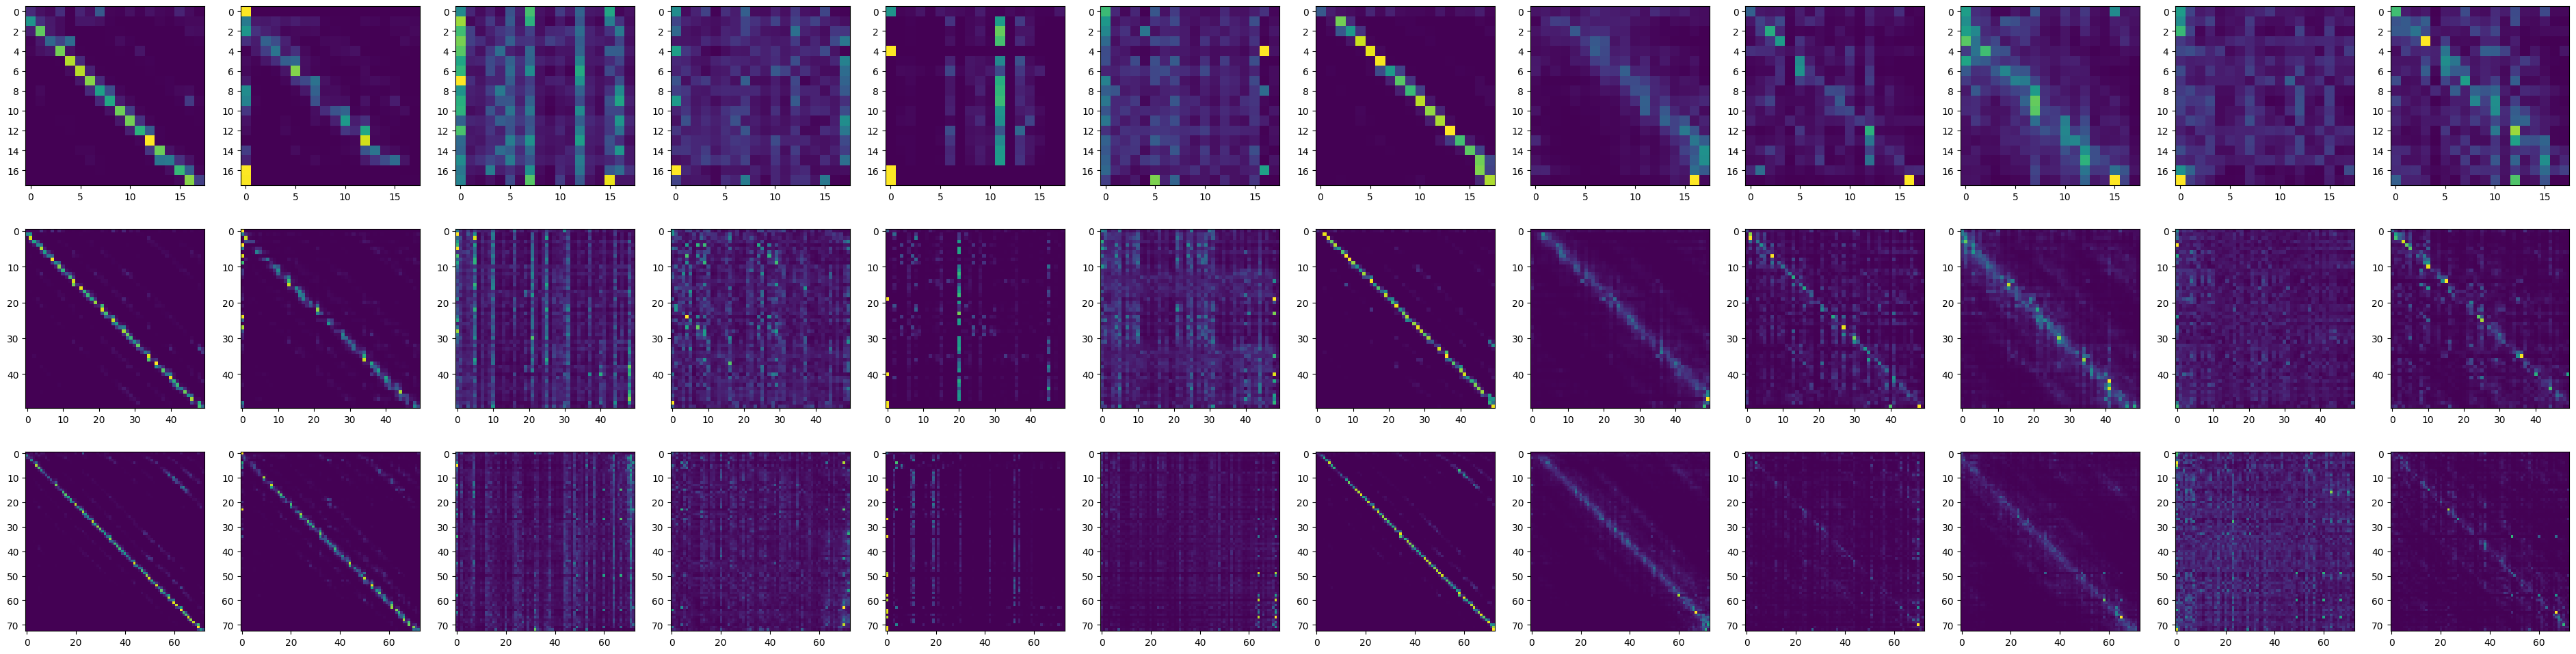

In [ ]:
draw_first_layer_attention_maps(mask, texts[0], rubert_tiny_transformer_model)

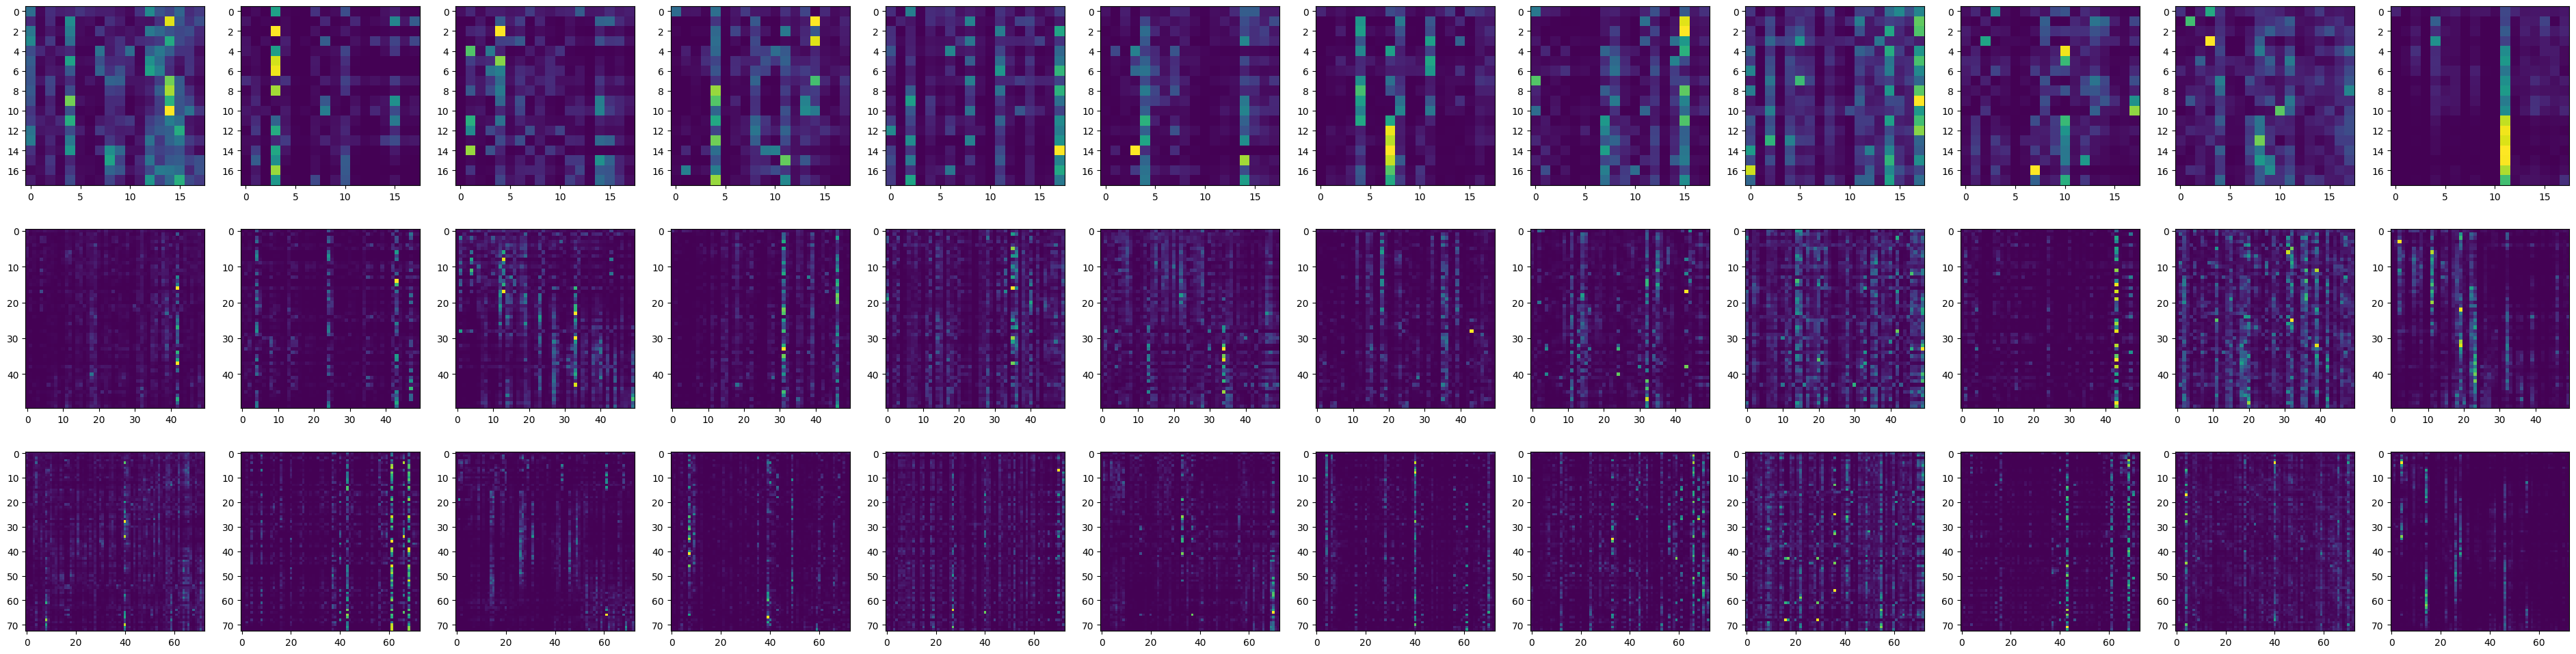

In [ ]:
draw_first_layer_attention_maps(mask, texts[0], transformer_model)

### Задание 8 (1 балл)

Сделайте то же самое для дообученных моделей. Изменились ли карты внимания и связи, которые они улавливают? Почему?

In [ ]:
draw_first_layer_attention_maps(mask, texts[0], rubert_tiny_finetuned_with_freezed_backbone)
draw_first_layer_attention_maps(mask, texts[0], rubert_tiny_full_finetuned)
draw_first_layer_attention_maps(mask, texts[0], MathBert_freezed)
draw_first_layer_attention_maps(mask, texts[0], MathBert)